<a href="https://colab.research.google.com/github/kevinayz/CACNA1C/blob/main/CACNA1C_Test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup


In [ ]:
from IPython.display import clear_output
! pip install alphagenome
clear_output()

In [ ]:
from google.colab import userdata
from alphagenome import colab_utils
from alphagenome.data import gene_annotation
from alphagenome.data import genome
from alphagenome.data import transcript as transcript_utils
from alphagenome.interpretation import ism
from alphagenome.models import dna_client
from alphagenome.models import variant_scorers
from alphagenome.visualization import plot_components
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

API_KEY = userdata.get('ALPHAGENOME_API_KEY')
dna_model = dna_client.create(API_KEY)

AttributeError: module 'numpy._core._multiarray_umath' has no attribute '_blas_supports_fpe'

In [ ]:
# Note that we use genome assembly hg38 for human.
gtf = pd.read_feather(
    'https://storage.googleapis.com/alphagenome/reference/gencode/'
    'hg38/gencode.v46.annotation.gtf.gz.feather'
)

gtf_transcripts = gene_annotation.filter_protein_coding(gtf)
gtf_transcripts = gene_annotation.filter_to_mane_select_transcript(gtf_transcripts)
transcript_extractor = transcript_utils.TranscriptExtractor(gtf_transcripts)

#rs11062170

In [ ]:
variant = genome.Variant(
    chromosome='chr12',
    position=2239678,
    reference_bases='G',  # Can differ from the true reference genome base.
    alternate_bases='C',
)

interval = variant.reference_interval.resize(dna_client.SEQUENCE_LENGTH_1MB)

In [ ]:
variant_output = dna_model.predict_variant(
    interval=interval,
    variant=variant,
    requested_outputs=[dna_client.OutputType.RNA_SEQ, dna_client.OutputType.CAGE, dna_client.OutputType.ATAC, dna_client.OutputType.DNASE],
    ontology_terms=['UBERON:0000955'],
)

In [ ]:
transcripts = transcript_extractor.extract(interval)

In [ ]:
# RNA-Seq

ref_rna_plus = variant_output.reference.rna_seq.filter_to_positive_strand()
alt_rna_plus = variant_output.alternate.rna_seq.filter_to_positive_strand()

# Plot 1: RNA-Seq
# Get CACNA1C transcripts from the extracted transcripts
cacna1c_transcripts = [
    t for t in transcripts
    if t.gene_id.startswith("ENSG00000151067")
]

# Choose the transcript (same logic as before)
canonical = max(
    cacna1c_transcripts,
    key=lambda t: t.transcript_interval.end - t.transcript_interval.start
)

# Sort exons by genomic position
exons = sorted(canonical.exons, key=lambda e: e.start)

# Exon immediately upstream of the variant
upstream_exon = max(
    (e for e in exons if e.end <= variant.position),
    key=lambda e: e.end,
)

# Exon immediately downstream of the variant
downstream_exon = min(
    (e for e in exons if e.start >= variant.position),
    key=lambda e: e.start,
)

print(f"Upstream exon:   {upstream_exon.start:,}-{upstream_exon.end:,}")
print(f"Downstream exon: {downstream_exon.start:,}-{downstream_exon.end:,}")

# Add padding so the exon boundaries aren't flush against the plot edges
pad = 5000

focus_interval = genome.Interval(
    chromosome=variant.chromosome,
    start=upstream_exon.start - pad,
    end=downstream_exon.end + pad,
)

plot_components.plot(
    [
        plot_components.TranscriptAnnotation(transcripts),
        plot_components.OverlaidTracks(
            tdata={"REF": ref_rna_plus, "ALT": alt_rna_plus},
            colors={"REF": "green", "ALT": "red"},
        ),
    ],
    interval=focus_interval,
    annotations=[plot_components.VariantAnnotation([variant], alpha=0.8)],
)
plt.show()

# Exon independent
pad = 50

for label, exon in [
    ("Upstream exon", upstream_exon),
    ("Downstream exon", downstream_exon),
]:
    exon_interval = genome.Interval(
        chromosome=variant.chromosome,
        start=exon.start - pad,
        end=exon.end + pad,
    )

    plot_components.plot(
        [
            plot_components.TranscriptAnnotation(transcripts),
            plot_components.OverlaidTracks(
                tdata={
                    "REF": ref_rna_plus,
                    "ALT": alt_rna_plus,
                },
                colors={
                    "REF": "green",
                    "ALT": "red",
                },
            ),
        ],
        interval=exon_interval,
        annotations=[
            plot_components.VariantAnnotation([variant], alpha=0.8)
        ],
    )

    plt.title(label)
    plt.show()

In [ ]:
# CAGE

ref_cage_plus = variant_output.reference.cage.filter_to_positive_strand()
alt_cage_plus = variant_output.alternate.cage.filter_to_positive_strand()

# 1. Find the exact CAGE peak position automatically
cage_iv = variant_output.reference.cage.interval

# Search window around the suspected TSS
search_start_genomic = 2052500
search_end_genomic   = 2053500

s = search_start_genomic - cage_iv.start
e = search_end_genomic   - cage_iv.start

# Position of max CAGE signal in REF (averaged across tracks)
peak_offset_local = int(np.argmax(ref_cage_plus.values[s:e].mean(axis=1)))
peak_pos = cage_iv.start + s + peak_offset_local

# 2. Build a very tight interval around the peak
half_window = 100   # ±100 bp → 200 bp total
peak_interval = genome.Interval(
    chromosome='chr12',
    start=peak_pos - half_window,
    end=peak_pos + half_window,
)

# A wider starting interval centered on peak, then resize
peak_interval = genome.Interval(
    chromosome='chr12',
    start=peak_pos - 1000,
    end=peak_pos + 1000,
).resize(2**6)

plot_components.plot(
    [
        plot_components.TranscriptAnnotation(transcripts, fig_height=0.3),
        plot_components.OverlaidTracks(
            tdata={'REF': ref_cage_plus, 'ALT': alt_cage_plus},
            colors={'REF': 'green', 'ALT': 'red'},
        ),
    ],
    interval=peak_interval,
)
plt.show()

In [ ]:
# ATAC-Seq
# Brain tissue
variant_output = dna_model.predict_variant(
    interval=interval,
    variant=variant,
    requested_outputs=[dna_client.OutputType.RNA_SEQ, dna_client.OutputType.CAGE, dna_client.OutputType.ATAC, dna_client.OutputType.DNASE],
    ontology_terms=['UBERON:0000955'],
)

ref_atac = variant_output.reference.atac
alt_atac = variant_output.alternate.atac

half_window = 1000  # ±1 kb around the SNP

atac_interval = genome.Interval(
    chromosome=variant.chromosome,
    start=variant.position - half_window,
    end=variant.position + half_window,
)

plot_components.plot(
    [
        plot_components.TranscriptAnnotation(transcripts, fig_height=0.3),
        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_atac,
                "ALT": alt_atac,
            },
            colors={
                "REF": "green",
                "ALT": "red",
            },
        ),
    ],
    interval=atac_interval,
    annotations=[
        plot_components.VariantAnnotation([variant], alpha=0.8)
    ],
)

plt.show()

# Lung tissue
variant_output = dna_model.predict_variant(
    interval=interval,
    variant=variant,
    requested_outputs=[dna_client.OutputType.RNA_SEQ, dna_client.OutputType.CAGE, dna_client.OutputType.ATAC, dna_client.OutputType.DNASE],
    ontology_terms=['UBERON:0002048'],
)

ref_atac = variant_output.reference.atac
alt_atac = variant_output.alternate.atac

half_window = 1000  # ±1 kb around the SNP

atac_interval = genome.Interval(
    chromosome=variant.chromosome,
    start=variant.position - half_window,
    end=variant.position + half_window,
)

plot_components.plot(
    [
        plot_components.TranscriptAnnotation(transcripts, fig_height=0.3),
        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_atac,
                "ALT": alt_atac,
            },
            colors={
                "REF": "green",
                "ALT": "red",
            },
        ),
    ],
    interval=atac_interval,
    annotations=[
        plot_components.VariantAnnotation([variant], alpha=0.8)
    ],
)

plt.show()

# Right liver lobe
variant_output = dna_model.predict_variant(
    interval=interval,
    variant=variant,
    requested_outputs=[dna_client.OutputType.RNA_SEQ, dna_client.OutputType.CAGE, dna_client.OutputType.ATAC, dna_client.OutputType.DNASE],
    ontology_terms=['UBERON:0001114'],
)

ref_atac = variant_output.reference.atac
alt_atac = variant_output.alternate.atac

half_window = 1000  # ±1 kb around the SNP

atac_interval = genome.Interval(
    chromosome=variant.chromosome,
    start=variant.position - half_window,
    end=variant.position + half_window,
)

plot_components.plot(
    [
        plot_components.TranscriptAnnotation(transcripts, fig_height=0.3),
        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_atac,
                "ALT": alt_atac,
            },
            colors={
                "REF": "green",
                "ALT": "red",
            },
        ),
    ],
    interval=atac_interval,
    annotations=[
        plot_components.VariantAnnotation([variant], alpha=0.8)
    ],
)

plt.show()

In [ ]:
# DNASE
variant_output = dna_model.predict_variant(
    interval=interval,
    variant=variant,
    requested_outputs=[dna_client.OutputType.RNA_SEQ, dna_client.OutputType.CAGE, dna_client.OutputType.ATAC, dna_client.OutputType.DNASE],
    ontology_terms=['UBERON:0000955'],
)

ref_dnase = variant_output.reference.dnase
alt_dnase = variant_output.alternate.dnase

half_window = 1000  # ±1 kb around the SNP

dnase_interval = genome.Interval(
    chromosome=variant.chromosome,
    start=variant.position - half_window,
    end=variant.position + half_window,
)

plot_components.plot(
    [
        plot_components.TranscriptAnnotation(transcripts, fig_height=0.3),
        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_dnase,
                "ALT": alt_dnase,
            },
            colors={
                "REF": "green",
                "ALT": "red",
            },
        ),
    ],
    interval=dnase_interval.resize(2**3),
    annotations=[
        plot_components.VariantAnnotation([variant], alpha=0.8)
    ],
)

plt.show()

# Find position of max |ALT − REF| across the full 1 Mb
ref_vals = np.asarray(ref_dnase.values).squeeze()
alt_vals = np.asarray(alt_dnase.values).squeeze()
if ref_vals.ndim > 1:
    ref_vals = ref_vals.mean(axis=tuple(range(1, ref_vals.ndim)))
    alt_vals = alt_vals.mean(axis=tuple(range(1, alt_vals.ndim)))

abs_diff = np.abs(alt_vals - ref_vals)
max_idx = int(np.argmax(abs_diff))
resolution = ref_dnase.resolution
max_diff_position = ref_dnase.interval.start + max_idx * resolution

print(f"SNP: {variant.chromosome}:{variant.position} "
      f"{variant.reference_bases}>{variant.alternate_bases}")
print(f"Max |ALT − REF| = {abs_diff[max_idx]:.4f}")
print(f"  Position: {variant.chromosome}:{max_diff_position} "
      f"(bin width = {resolution} bp)")
print(f"  REF = {ref_vals[max_idx]:.4f},  ALT = {alt_vals[max_idx]:.4f}")
print(f"  Distance from SNP: {max_diff_position - variant.position:+d} bp")

# All SNPs DNase data


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving CACNA1C_SNPs_Copy.xlsx to CACNA1C_SNPs_Copy.xlsx


In [ ]:
import pandas as pd
import numpy as np

# === Load your spreadsheet ===
df = pd.read_excel("CACNA1C_SNPs_Copy.xlsx", sheet_name=0, engine="openpyxl")

half_window = 1000  # ±1 kb around the SNP
results = []

for _, row in df.iterrows():
    rsid = row["name"]
    chrom = row["chr#"]
    pos = int(row["end"])
    prot_allele = row["Prot_allele"]
    risk_allele = row["risk_allele"]

    # Build variant object: protective = reference, risk = alternate
    variant = genome.Variant(
        chromosome=chrom,
        position=pos,
        reference_bases=prot_allele,
        alternate_bases=risk_allele,
    )

    # Build interval around SNP
    interval = variant.reference_interval.resize(dna_client.SEQUENCE_LENGTH_1MB)

    # Run prediction
    variant_output = dna_model.predict_variant(
        interval=interval,
        variant=variant,
        requested_outputs=[dna_client.OutputType.DNASE],
        ontology_terms=["UBERON:0000955"],
    )

    prot_dnase = variant_output.reference.dnase
    risk_dnase = variant_output.alternate.dnase

    # Locate SNP within the DNase track
    track_interval = prot_dnase.interval
    resolution = prot_dnase.resolution
    snp_index = (pos - track_interval.start) // resolution

    prot_val = float(np.asarray(prot_dnase.values)[snp_index].squeeze())
    risk_val = float(np.asarray(risk_dnase.values)[snp_index].squeeze())

    diff = risk_val - prot_val  # risk - protective

    results.append({
        "chromosome": chrom,
        "rsid": rsid,
        "position": pos,
        "prot_allele": prot_allele,
        "risk_allele": risk_allele,
        "prot_dnase": prot_val,
        "risk_dnase": risk_val,
        "risk_minus_prot": diff,
    })

# Convert to DataFrame and sort by largest magnitude difference
results_df = pd.DataFrame(results)
results_df = results_df.reindex(
    results_df["risk_minus_prot"].abs().sort_values(ascending=False).index
).reset_index(drop=True)

results_df.to_excel("CACNA1C_DNase_results.xlsx", index=False, engine="openpyxl")

from google.colab import files
files.download("CACNA1C_DNase_results.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import numpy as np

# === Load your spreadsheet ===
df = pd.read_excel("CACNA1C_SNPs_Copy.xlsx", sheet_name=0, engine="openpyxl")

results = []

for _, row in df.iterrows():
    rsid = row["name"]
    chrom = row["chr#"]
    pos = int(row["end"])
    prot_allele = row["Prot_allele"]
    risk_allele = row["risk_allele"]

    # Build variant object: protective = reference, risk = alternate
    variant = genome.Variant(
        chromosome=chrom,
        position=pos,
        reference_bases=prot_allele,
        alternate_bases=risk_allele,
    )

    # Build 1 Mb interval around SNP
    interval = variant.reference_interval.resize(dna_client.SEQUENCE_LENGTH_1MB)

    # Run prediction
    variant_output = dna_model.predict_variant(
        interval=interval,
        variant=variant,
        requested_outputs=[dna_client.OutputType.DNASE],
        ontology_terms=["UBERON:0000955"],
    )

    prot_dnase = variant_output.reference.dnase
    risk_dnase = variant_output.alternate.dnase

    # Convert to numpy arrays
    prot_vals = np.asarray(prot_dnase.values).squeeze()
    risk_vals = np.asarray(risk_dnase.values).squeeze()

    # If multi-track (e.g., multiple tissues), collapse extra dims by taking mean across tracks
    # Keep only the positional axis
    if prot_vals.ndim > 1:
        prot_vals = prot_vals.mean(axis=tuple(range(1, prot_vals.ndim)))
        risk_vals = risk_vals.mean(axis=tuple(range(1, risk_vals.ndim)))

    # Compute position-wise difference across entire 1 Mb interval
    diff_track = risk_vals - prot_vals
    abs_diff_track = np.abs(diff_track)

    # Find the position of max absolute difference
    max_idx = int(np.argmax(abs_diff_track))
    max_abs_diff = float(abs_diff_track[max_idx])
    max_signed_diff = float(diff_track[max_idx])

    # Convert bin index back to genomic coordinate
    track_interval = prot_dnase.interval
    resolution = prot_dnase.resolution
    max_diff_position = int(track_interval.start + max_idx * resolution)

    # Values at the max-difference position
    prot_val_at_max = float(prot_vals[max_idx])
    risk_val_at_max = float(risk_vals[max_idx])

    # Also keep the value at the SNP itself for reference
    snp_index = (pos - track_interval.start) // resolution
    prot_val_at_snp = float(prot_vals[snp_index])
    risk_val_at_snp = float(risk_vals[snp_index])

    results.append({
        "chromosome": chrom,
        "rsid": rsid,
        "snp_position": pos,
        "prot_allele": prot_allele,
        "risk_allele": risk_allele,
        "prot_dnase_at_snp": prot_val_at_snp,
        "risk_dnase_at_snp": risk_val_at_snp,
        "max_diff_position": max_diff_position,
        "distance_from_snp": max_diff_position - pos,
        "prot_dnase_at_max": prot_val_at_max,
        "risk_dnase_at_max": risk_val_at_max,
        "max_signed_diff": max_signed_diff,
        "max_abs_diff": max_abs_diff,
    })

# Convert to DataFrame and sort by largest absolute difference anywhere in the interval
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(
    by="max_abs_diff", ascending=False
).reset_index(drop=True)

results_df.to_excel("CACNA1C_DNase_results_1Mb.xlsx", index=False, engine="openpyxl")

from google.colab import files
files.download("CACNA1C_DNase_results_1Mb.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# RNA-seq SNP positive control

In [ ]:
#rs10774671
variant = genome.Variant(
    chromosome='chr12',
    position=112919388,   # hg38 — verify
    reference_bases='G',
    alternate_bases='A',
)

interval = variant.reference_interval.resize(dna_client.SEQUENCE_LENGTH_1MB)

variant_output = dna_model.predict_variant(
    interval=interval,
    variant=variant,
    requested_outputs=[dna_client.OutputType.RNA_SEQ],
    ontology_terms=['UBERON:0000955'], # whole blood
)

transcripts = transcript_extractor.extract(interval)

Variant position: 112,919,388
OAS1 span: 112,906,961-112,919,903 (strand +)
  Exon 1: 112,906,961-112,907,219
  Exon 2: 112,908,535-112,908,824
  Exon 3: 112,911,050-112,911,235
  Exon 4: 112,916,508-112,916,738
  Exon 5: 112,917,546-112,917,700
  Exon 6: 112,919,388-112,919,903  <-- closest to variant

Upstream exon:   112,917,546-112,917,700
Downstream exon: 112,919,388-112,919,903


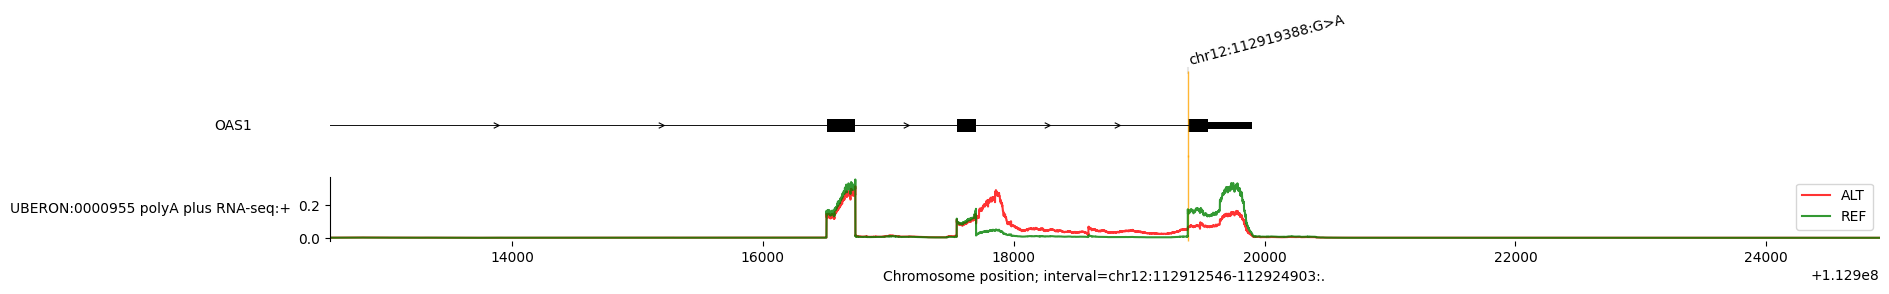

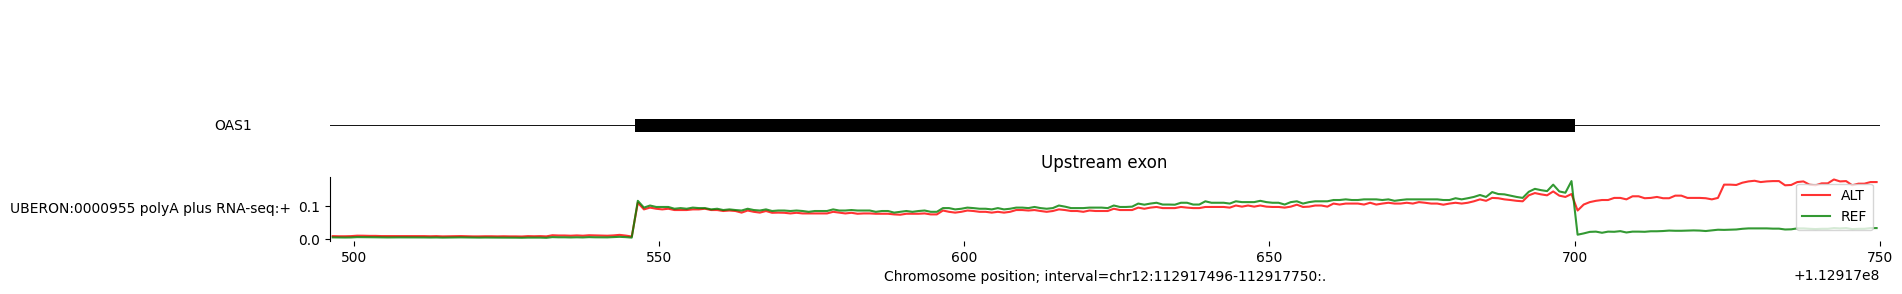

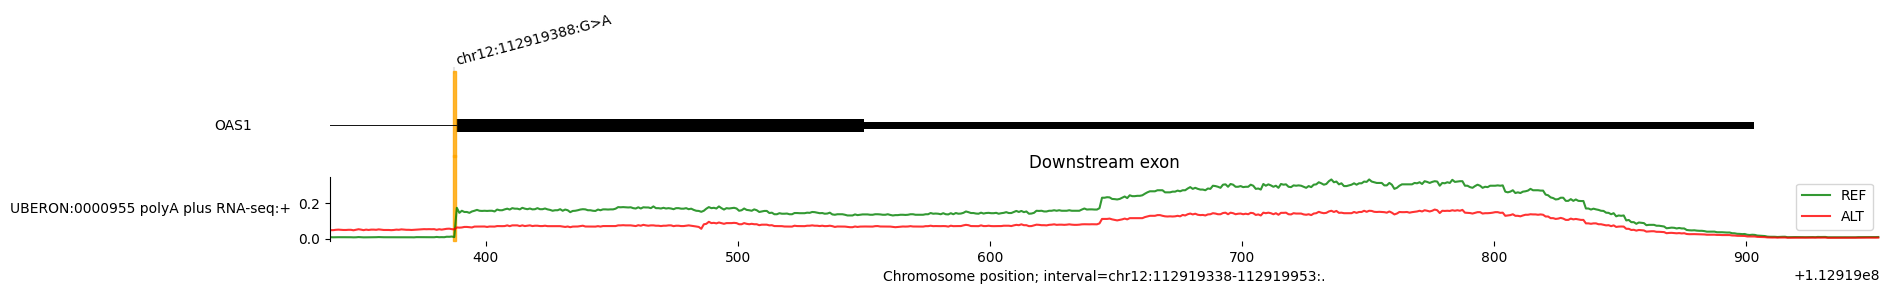

In [ ]:
# RNA-Seq — OAS1 is on the positive strand
ref_rna_plus = variant_output.reference.rna_seq.filter_to_positive_strand()
alt_rna_plus = variant_output.alternate.rna_seq.filter_to_positive_strand()

# Plot 1: RNA-Seq around the variant, focused on flanking exons
# OAS1 Ensembl gene ID
oas1_transcripts = [
    t for t in transcripts
    if t.gene_id.startswith("ENSG00000089127")   # OAS1
]

# Fallback: any transcript overlapping the variant
if not oas1_transcripts:
    oas1_transcripts = [
        t for t in transcripts
        if t.transcript_interval.start <= variant.position <= t.transcript_interval.end
    ]

# Choose the longest transcript as canonical
canonical = max(
    oas1_transcripts,
    key=lambda t: t.transcript_interval.end - t.transcript_interval.start,
)

# Sort exons by genomic position
exons = sorted(canonical.exons, key=lambda e: e.start)

# Diagnostic: show which exon(s) the variant is near
print(f"Variant position: {variant.position:,}")
print(f"OAS1 span: {canonical.transcript_interval.start:,}-"
      f"{canonical.transcript_interval.end:,} (strand {canonical.strand})")
for i, e in enumerate(exons, start=1):
    marker = "  <-- closest to variant" if e.start <= variant.position <= e.end else ""
    print(f"  Exon {i}: {e.start:,}-{e.end:,}{marker}")

# Exon immediately upstream of the variant (may not exist if variant is 5' of gene)
upstream_candidates = [e for e in exons if e.end <= variant.position]
downstream_candidates = [e for e in exons if e.start >= variant.position]

upstream_exon = max(upstream_candidates, key=lambda e: e.end) if upstream_candidates else None
downstream_exon = min(downstream_candidates, key=lambda e: e.start) if downstream_candidates else None

if upstream_exon:
    print(f"\nUpstream exon:   {upstream_exon.start:,}-{upstream_exon.end:,}")
else:
    print("\nUpstream exon:   (none — variant is 5' of gene body)")

if downstream_exon:
    print(f"Downstream exon: {downstream_exon.start:,}-{downstream_exon.end:,}")
else:
    print("Downstream exon: (none — variant is 3' of gene body)")

# Build focus interval spanning whichever flanking exons exist
pad = 5000
if upstream_exon and downstream_exon:
    focus_start = upstream_exon.start - pad
    focus_end = downstream_exon.end + pad
elif downstream_exon:
    focus_start = variant.position - pad
    focus_end = downstream_exon.end + pad
elif upstream_exon:
    focus_start = upstream_exon.start - pad
    focus_end = variant.position + pad
else:
    focus_start = variant.position - pad
    focus_end = variant.position + pad

focus_interval = genome.Interval(
    chromosome=variant.chromosome,
    start=focus_start,
    end=focus_end,
)

plot_components.plot(
    [
        plot_components.TranscriptAnnotation(transcripts),
        plot_components.OverlaidTracks(
            tdata={"REF": ref_rna_plus, "ALT": alt_rna_plus},
            colors={"REF": "green", "ALT": "red"},
        ),
    ],
    interval=focus_interval,
    annotations=[plot_components.VariantAnnotation([variant], alpha=0.8)],
)
plt.show()

# Individual exon zoom-ins
pad = 50
exons_to_plot = []
if upstream_exon:
    exons_to_plot.append(("Upstream exon", upstream_exon))
if downstream_exon:
    exons_to_plot.append(("Downstream exon", downstream_exon))

for label, exon in exons_to_plot:
    exon_interval = genome.Interval(
        chromosome=variant.chromosome,
        start=exon.start - pad,
        end=exon.end + pad,
    )
    plot_components.plot(
        [
            plot_components.TranscriptAnnotation(transcripts),
            plot_components.OverlaidTracks(
                tdata={"REF": ref_rna_plus, "ALT": alt_rna_plus},
                colors={"REF": "green", "ALT": "red"},
            ),
        ],
        interval=exon_interval,
        annotations=[plot_components.VariantAnnotation([variant], alpha=0.8)],
    )
    plt.title(label)
    plt.show()


    ### CURRENT PROBLEM RNA-sEQ not shwoing up for whole blood tissue, but very prevalent for brain
    #Next step, try this with different tissue to verify its a problem with the whole blood tissue
    # tyr atac seq with whole blood to verify atac seq is problem with brain tissue and not wide throughout

# Test Area


In [ ]:
# brain
variant_output = dna_model.predict_variant(
    interval=interval,
    variant=variant,
    requested_outputs=[dna_client.OutputType.RNA_SEQ, dna_client.OutputType.CAGE, dna_client.OutputType.ATAC, dna_client.OutputType.DNASE],
    ontology_terms=['UBERON:0000955'],
)

ref_atac = variant_output.reference.atac
alt_atac = variant_output.alternate.atac

print(ref_atac.num_tracks)
print(ref_atac.names)
print(ref_atac.values.shape)



# lung
variant_output = dna_model.predict_variant(
    interval=interval,
    variant=variant,
    requested_outputs=[dna_client.OutputType.RNA_SEQ, dna_client.OutputType.CAGE, dna_client.OutputType.ATAC, dna_client.OutputType.DNASE],
    ontology_terms=['UBERON:0002048'],
)

ref_atac = variant_output.reference.atac
alt_atac = variant_output.alternate.atac

print(ref_atac.num_tracks)
print(ref_atac.names)
print(ref_atac.values.shape)



# right liver lobe
variant_output = dna_model.predict_variant(
    interval=interval,
    variant=variant,
    requested_outputs=[dna_client.OutputType.RNA_SEQ, dna_client.OutputType.CAGE, dna_client.OutputType.ATAC, dna_client.OutputType.DNASE],
    ontology_terms=['UBERON:0001114'],
)

ref_atac = variant_output.reference.atac
alt_atac = variant_output.alternate.atac

print(ref_atac.num_tracks)
print(ref_atac.names)
print(ref_atac.values.shape)


0
[]
(1048576, 0)
1
['UBERON:0002048 ATAC-seq']
(1048576, 1)
1
['UBERON:0001114 ATAC-seq']
(1048576, 1)


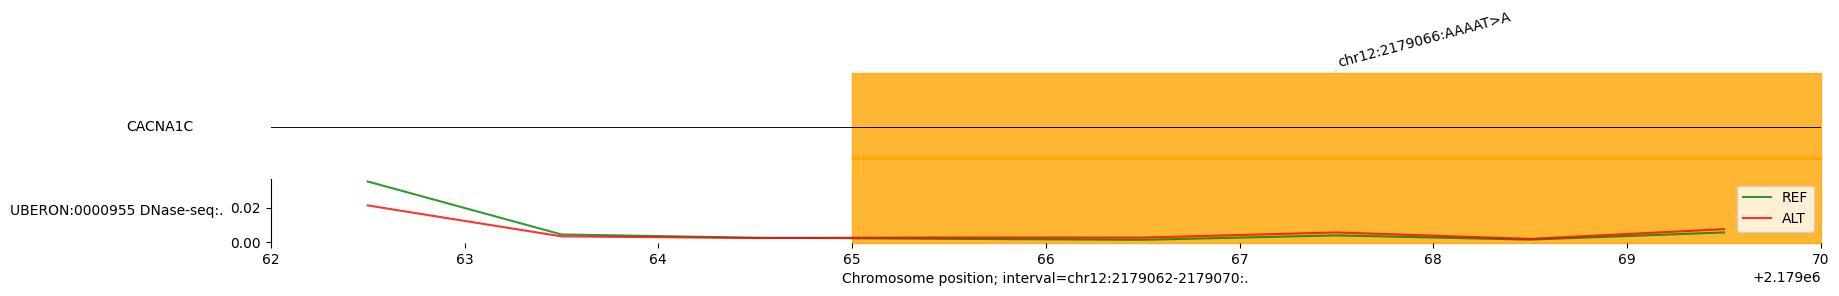

SNP: chr12:2179066 AAAAT>A
Max |ALT − REF| = 13.2773
  Position: chr12:2213541 (bin width = 1 bp)
  REF = 0.8477,  ALT = 14.1250
  Distance from SNP: +34475 bp


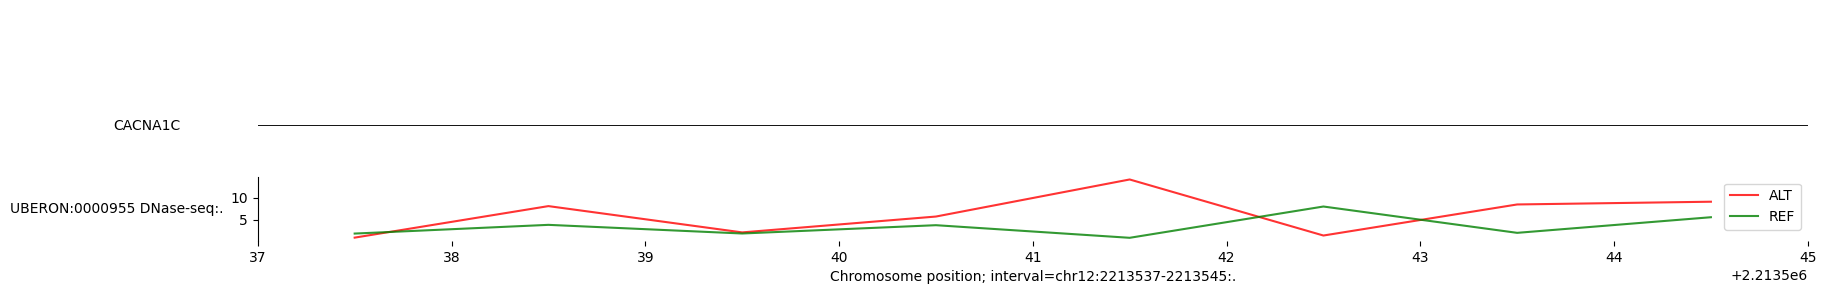

In [ ]:
variant = genome.Variant(
    chromosome='chr12',
    position=2179066,
    reference_bases='AAAAT',  # Can differ from the true reference genome base.
    alternate_bases='A',
)

interval = variant.reference_interval.resize(dna_client.SEQUENCE_LENGTH_1MB)

# DNASE
variant_output = dna_model.predict_variant(
    interval=interval,
    variant=variant,
    requested_outputs=[dna_client.OutputType.RNA_SEQ, dna_client.OutputType.CAGE, dna_client.OutputType.ATAC, dna_client.OutputType.DNASE],
    ontology_terms=['UBERON:0000955'],
)

ref_dnase = variant_output.reference.dnase
alt_dnase = variant_output.alternate.dnase

half_window = 1000  # ±1 kb around the SNP

dnase_interval = genome.Interval(
    chromosome=variant.chromosome,
    start=variant.position - half_window,
    end=variant.position + half_window,
)

plot_components.plot(
    [
        plot_components.TranscriptAnnotation(transcripts, fig_height=0.3),
        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_dnase,
                "ALT": alt_dnase,
            },
            colors={
                "REF": "green",
                "ALT": "red",
            },
        ),
    ],
    interval=dnase_interval.resize(2**3),
    annotations=[
        plot_components.VariantAnnotation([variant], alpha=0.8)
    ],
)

plt.show()

# Find position of max |ALT − REF| across the full 1 Mb
ref_vals = np.asarray(ref_dnase.values).squeeze()
alt_vals = np.asarray(alt_dnase.values).squeeze()
if ref_vals.ndim > 1:
    ref_vals = ref_vals.mean(axis=tuple(range(1, ref_vals.ndim)))
    alt_vals = alt_vals.mean(axis=tuple(range(1, alt_vals.ndim)))

abs_diff = np.abs(alt_vals - ref_vals)
max_idx = int(np.argmax(abs_diff))
resolution = ref_dnase.resolution
max_diff_position = ref_dnase.interval.start + max_idx * resolution

print(f"SNP: {variant.chromosome}:{variant.position} "
      f"{variant.reference_bases}>{variant.alternate_bases}")
print(f"Max |ALT − REF| = {abs_diff[max_idx]:.4f}")
print(f"  Position: {variant.chromosome}:{max_diff_position} "
      f"(bin width = {resolution} bp)")
print(f"  REF = {ref_vals[max_idx]:.4f},  ALT = {alt_vals[max_idx]:.4f}")
print(f"  Distance from SNP: {max_diff_position - variant.position:+d} bp")

# --- Plot 2: ±1 kb around the max-difference location ---
max_diff_interval = genome.Interval(
    chromosome=variant.chromosome,
    start=max_diff_position - half_window,
    end=max_diff_position + half_window,
)
plot_components.plot(
    [
        plot_components.TranscriptAnnotation(transcripts, fig_height=0.3),
        plot_components.OverlaidTracks(
            tdata={"REF": ref_dnase, "ALT": alt_dnase},
            colors={"REF": "green", "ALT": "red"},
        ),
    ],
    interval=max_diff_interval.resize(2**3),
    annotations=[plot_components.VariantAnnotation([variant], alpha=0.8)],
)
plt.show()